# SpectralKappa Experiments

**Goal**: Investigate whether spectral correction can reduce the effective
condition number $\kappa_{\rm eff}$ in QSVT, and whether $\tau$ remains
controlled under the minimax LP formulation (Mechanism 2).

**Central question**: Does $\tau_{SC} \approx \kappa$ (viable) or
$\tau_{SC} \gg \kappa$ (defeated by oscillations in $[\lambda_1,\lambda_K]$)?

**References**
- `Chapter18.tex` — QSVT degree $d = O(\sqrt{\kappa}\log 1/\varepsilon)$
- `SpectralCorrection.tex` — Gram-system spectral correction
- `MinimaxCorrection.py` — minimax $\tau$-controlled correction (this project)


## 0. Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from MinimaxCorrection  import MinimaxCorrection, effective_kappa
from PolynomialApproximators import (
    MangPolynomial, RemezPolynomial, SunderhaufPolynomial,
    spectral_correction
)
from PoissonFunctions import (
    build_1d_poisson, eigs_1d_poisson,
    build_2d_poisson, eigs_2d_poisson
)
from QSVTSolvers import StandardQSVT, SpectrallyBootstrappedQSVT

plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
print('Imports OK')


Imports OK


## 1. Effective Condition Number vs K (1D Poisson)

Verify the theoretical prediction: correcting the $K$ smallest eigenvalues
raises the effective left endpoint from $\lambda_1$ to $\lambda_{K+1}$,
giving $\kappa_{\rm eff} \approx \kappa/(K+1)^2$ for 1D Poisson.


m=4, N=16, kappa=116.5


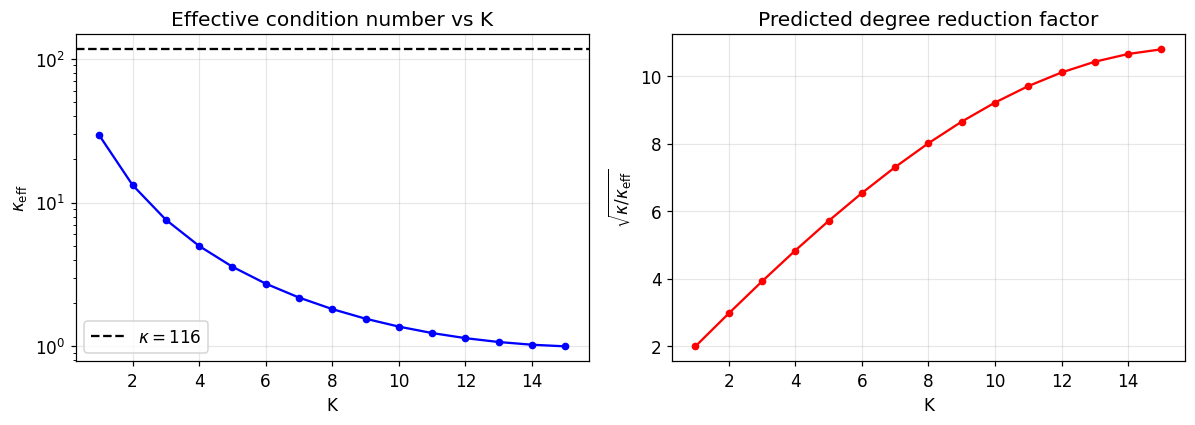

In [2]:
m = 4                                     # N = 2^m interior nodes
lams_raw  = eigs_1d_poisson(m)            # raw FD eigenvalues
lam_max   = lams_raw.max()
lams_norm = lams_raw / lam_max            # normalized to (0, 1]
kappa     = lams_norm.max() / lams_norm.min()
N         = len(lams_norm)
print(f'm={m}, N={N}, kappa={kappa:.1f}')

K_values = list(range(1, N))
eff_list = [effective_kappa(lams_norm, K) for K in K_values]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogy(K_values, [e['kappa_eff'] for e in eff_list], 'b-o', ms=4)
axes[0].axhline(kappa, color='k', ls='--', label=fr'$\kappa={kappa:.0f}$')
axes[0].set_xlabel('K'); axes[0].set_ylabel(r'$\kappa_{\rm eff}$')
axes[0].set_title('Effective condition number vs K'); axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_values, [e['degree_reduction_factor'] for e in eff_list], 'r-o', ms=4)
axes[1].set_xlabel('K'); axes[1].set_ylabel(r'$\sqrt{\kappa/\kappa_{\rm eff}}$')
axes[1].set_title('Predicted degree reduction factor')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_kappa_eff_vs_K_1d.png', bbox_inches='tight')
plt.show()


## 2. Tau vs K — The Critical Test (1D Poisson)

At each $K$, the base polynomial is designed over $[\lambda_{K+1}, 1]$
with a loose tolerance $\varepsilon = 0.5$, then the minimax LP corrects
the $K$ smallest eigenvalues while minimizing $\tau$.

- If $\tau_{SC} \approx \kappa$ across $K$: Mechanism 2 is viable
- If $\tau_{SC} \gg \kappa$: oscillations in $[\lambda_1, \lambda_K]$ dominate


K= 1 | d=  45 | tau_SC=  308.97 | tau_base=   18.56 | status=optimal
K= 2 | d=  21 | tau_SC=20021.76 | tau_base=    8.61 | status=optimal
K= 3 | d=  11 | tau_SC=     nan | tau_base=     nan | status=infeasible
K= 4 | d=   7 | tau_SC=     nan | tau_base=     nan | status=infeasible
K= 5 | d=   5 | tau_SC=     nan | tau_base=     nan | status=infeasible
K= 6 | d=   3 | tau_SC=     nan | tau_base=     nan | status=infeasible
K= 7 | d=   3 | tau_SC=     nan | tau_base=     nan | status=infeasible
K= 8 | d=   3 | tau_SC=     nan | tau_base=     nan | status=infeasible
K= 9 | d=   1 | tau_SC=     nan | tau_base=     nan | status=infeasible
K=10 | d=   1 | tau_SC=     nan | tau_base=     nan | status=infeasible
K=11 | d=   1 | tau_SC=     nan | tau_base=     nan | status=infeasible
K=12 | d=   1 | tau_SC=     nan | tau_base=     nan | status=infeasible
K=13 | d=   1 | tau_SC=     nan | tau_base=     nan | status=infeasible
K=14 | d=   1 | tau_SC=     nan | tau_base=     nan | status=infeasibl

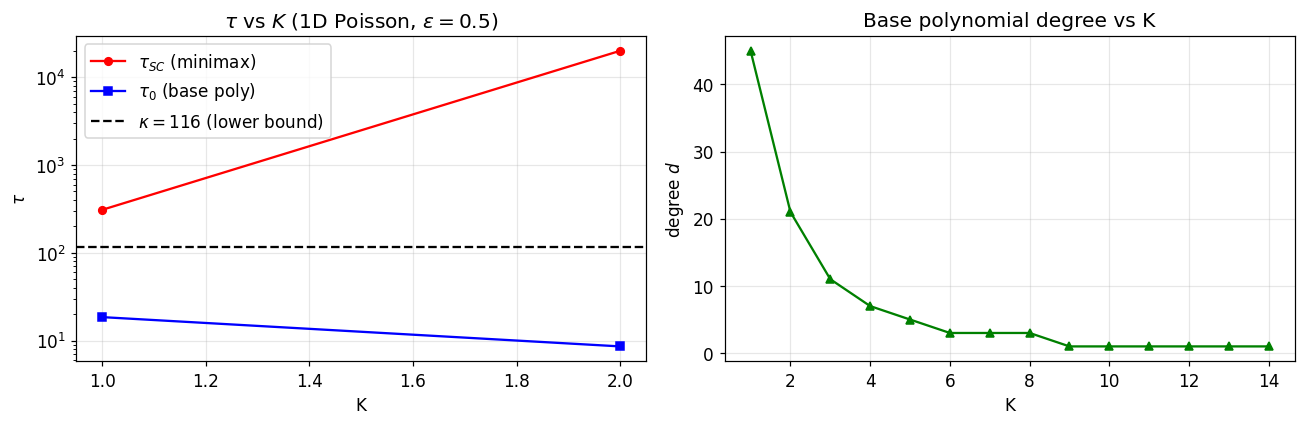

In [3]:
eps_loose = 0.5
m         = 4
lams_raw  = eigs_1d_poisson(m)
lam_max   = lams_raw.max()
lams_norm = lams_raw / lam_max
kappa     = lams_norm.max() / lams_norm.min()
N         = len(lams_norm)

K_values  = list(range(1, N - 1))  # stop at N-2: lams_norm[N-1]=1.0 is excluded
tau_sc    = []
tau_base  = []
degrees   = []

for K in K_values:
    a_eff = min(lams_norm[K], 1.0 - 1e-10)   # lambda_{K+1}, strictly < 1
    d     = MangPolynomial.mindegree(eps_loose, a_eff)
    p0    = MangPolynomial.poly(d, a_eff)

    solver = MinimaxCorrection(p0, lams_norm[:K])
    result = solver.solve()

    tau_sc.append(result['tau'])
    tau_base.append(result['tau_base'])
    degrees.append(d)
    print(f'K={K:2d} | d={d:4d} | tau_SC={result["tau"]:8.2f} | '
          f'tau_base={result["tau_base"]:8.2f} | status={result["status"]}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(K_values, tau_sc,   'r-o', ms=5, label=r'$\tau_{SC}$ (minimax)')
axes[0].semilogy(K_values, tau_base, 'b-s', ms=5, label=r'$\tau_0$ (base poly)')
axes[0].axhline(kappa, color='k', ls='--', label=fr'$\kappa={kappa:.0f}$ (lower bound)')
axes[0].set_xlabel('K'); axes[0].set_ylabel(r'$\tau$')
axes[0].set_title(r'$\tau$ vs $K$ (1D Poisson, $\varepsilon=0.5$)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(K_values, degrees, 'g-^', ms=5)
axes[1].set_xlabel('K'); axes[1].set_ylabel('degree $d$')
axes[1].set_title('Base polynomial degree vs K')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_tau_vs_K_1d.png', bbox_inches='tight')
plt.show()


## 3. Polynomial Visualization at Fixed K (1D Poisson)

Inspect $p_0$, $p_{SC}$, and compliance error $|x p(x) - 1|$
for a fixed $K$ to understand qualitatively how the correction behaves.


In [4]:
K         = 4
eps_loose = 0.5
m         = 4
lams_raw  = eigs_1d_poisson(m)
lam_max   = lams_raw.max()
lams_norm = lams_raw / lam_max
kappa     = lams_norm.max() / lams_norm.min()

a_eff = lams_norm[K]
d     = MangPolynomial.mindegree(eps_loose, a_eff)
p0    = MangPolynomial.poly(d, a_eff)

solver = MinimaxCorrection(p0, lams_norm[:K])
result = solver.solve()

print(f'kappa       = {kappa:.2f}')
print(f'tau_base    = {result["tau_base"]:.3f}')
print(f'tau_SC      = {result["tau"]:.3f}')
print(f'residuals   = {result["residuals"]}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
solver.plot_polynomials(result, ax=axes[0])
axes[0].set_title(f'Polynomial: K={K}, eps={eps_loose}, d={d}')
solver.plot_compliance_error(result, ax=axes[1])
axes[1].set_title(f'Compliance error: K={K}')
plt.tight_layout()
plt.savefig(f'fig_poly_K{K}.png', bbox_inches='tight')
plt.show()


kappa       = 116.46
tau_base    = nan
tau_SC      = nan


KeyError: 'residuals'

## 4. Degree Comparison Across Methods (1D Poisson)

Compare polynomial degree $d$ needed across three methods:
1. **Tight Mang**: base on $[\lambda_1, 1]$, $\varepsilon = 10^{-3}$
2. **SpectralCorrection-Mang** (Gram): loose base on $[\lambda_1, 1]$, $\varepsilon = 0.5$
3. **SpectralKappa-Mang** (minimax): loose base on $[\lambda_{K+1}, 1]$, $\varepsilon = 0.5$


In [ ]:
m         = 4
K         = 4
eps_tight = 1e-3
eps_loose = 0.5
lams_raw  = eigs_1d_poisson(m)
lam_max   = lams_raw.max()
lams_norm = lams_raw / lam_max
kappa     = lams_norm.max() / lams_norm.min()
a_full    = lams_norm[0]     # full left endpoint
a_eff     = lams_norm[K]     # raised left endpoint

# Method 1: tight Mang over full interval
d_tight = MangPolynomial.mindegree(eps_tight, a_full)

# Method 2: loose Mang over full interval (SpectralCorrection base)
d_loose = MangPolynomial.mindegree(eps_loose, a_full)

# Method 3: loose Mang over raised interval (SpectralKappa base)
d_sk    = MangPolynomial.mindegree(eps_loose, a_eff)

eff = effective_kappa(lams_norm, K)

print(f'kappa                          = {kappa:.1f}')
print(f'kappa_eff  (K={K})             = {eff["kappa_eff"]:.1f}')
print(f'Predicted degree factor         = {eff["degree_reduction_factor"]:.2f}x')
print()
print(f'Method                          | degree')
print(f'Tight Mang  (eps=1e-3, full)    | {d_tight}')
print(f'Loose Mang  (eps=0.5,  full)    | {d_loose}')
print(f'SpectralKappa (eps=0.5, K={K})   | {d_sk}')
print(f'Actual degree reduction          = {d_tight / d_sk:.2f}x')


## 5. QSVT Pipeline Comparison (1D Poisson)

Run the full QSVT pipeline comparing Standard, SpectrallyBootstrapped
(Gram), and SpectralKappa (minimax) methods.

**Note**: Matrix A must be normalized so all singular values lie in $(0,1]$.
We normalize by $\lambda_{\max}$: `A_norm = A / lam_max`.


In [ ]:
m         = 4
K         = 4
eps_loose = 0.5
eps_tight = 1e-3

A, b      = build_1d_poisson(m, function_type='uniform')
lams_raw  = eigs_1d_poisson(m)
lam_max   = lams_raw.max()
A_norm    = A / lam_max                   # normalize for block encoding
lams_norm = lams_raw / lam_max            # eigenvalues in (0, 1]
kappa     = lams_norm.max() / lams_norm.min()
a_full    = lams_norm[0]
a_eff     = lams_norm[K]

results = []

# Method 1: Standard QSVT (tight Mang)
d_tight  = MangPolynomial.mindegree(eps_tight, a_full)
qsvt_std = StandardQSVT(A_norm, b, kappa=kappa,
                         polyMethod='Mang',
                         target_error=eps_tight)
u1, p1, _ = qsvt_std.solve(stateVector=True)
x_true    = np.linalg.solve(A_norm, b)
x_true   /= np.linalg.norm(x_true)
fid1      = float(np.abs(u1 @ x_true))**2
results.append({'Method': 'Standard Mang (eps=1e-3)',
                'Degree': d_tight, 'Fidelity': fid1,
                'P_succ': p1, 'tau': qsvt_std.tau})

# Method 2: SpectrallyBootstrapped (Gram, loose base over full interval)
d_loose   = MangPolynomial.mindegree(eps_loose, a_full)
qsvt_sc   = SpectrallyBootstrappedQSVT(A_norm, b,
                                        lam_K=lams_norm[:K],
                                        kappa=kappa,
                                        polyMethod='Mang',
                                        target_error=eps_loose)
u2, p2, _ = qsvt_sc.solve(stateVector=True)
fid2      = float(np.abs(u2 @ x_true))**2
results.append({'Method': f'SpectralCorrection-Mang (Gram, K={K})',
                'Degree': d_loose, 'Fidelity': fid2,
                'P_succ': p2, 'tau': qsvt_sc.tau})

# Method 3: SpectralKappa (minimax, loose base over raised interval)
d_sk      = MangPolynomial.mindegree(eps_loose, a_eff)
p0_sk     = MangPolynomial.poly(d_sk, a_eff)
mm        = MinimaxCorrection(p0_sk, lams_norm[:K])
res_mm    = mm.solve()
p_SC      = res_mm['p_SC']

# Plug corrected polynomial into StandardQSVT via degree_override
qsvt_sk   = StandardQSVT(A_norm, b, kappa=kappa,
                          polyMethod='Mang',
                          degree_override=d_sk)
# Override the phases with those from p_SC
# (Re-use StandardQSVT's normalisation pipeline by patching the polynomial)
# Direct approach: compute phases from p_SC manually
from numpy.polynomial.chebyshev import Chebyshev
from pyqsp.angle_sequence import QuantumSignalProcessingPhases
N_sample   = 25 * d_sk
x_s        = np.linspace(-1, 1, N_sample)
M          = np.max(np.abs(p_SC(x_s))) / np.cos(np.pi * d_sk / (2 * N_sample))
tau_sk     = M
p_SC_norm  = Chebyshev(p_SC.coef / M)
max_val    = np.max(np.abs(p_SC_norm(np.linspace(-1, 1, 2000))))
if max_val > 0.999:
    scale      = 0.999 / max_val
    p_SC_norm  = Chebyshev(p_SC_norm.coef * scale)
    tau_sk    /= scale
phases_sk  = QuantumSignalProcessingPhases(p_SC_norm, signal_operator='Wx')
qsvt_sk.angles = [float(ph) for ph in phases_sk]
qsvt_sk.tau    = tau_sk

u3, p3, _ = qsvt_sk.solve(stateVector=True)
fid3      = float(np.abs(u3 @ x_true))**2
results.append({'Method': f'SpectralKappa-Mang (minimax, K={K})',
                'Degree': d_sk, 'Fidelity': fid3,
                'P_succ': p3, 'tau': tau_sk})

# Print table
print(f'{"Method":<45} {"Degree":>8} {"Fidelity":>10} {"P_succ":>8} {"tau":>8}')
print('-' * 82)
for r in results:
    print(f'{r["Method"]:<45} {r["Degree"]:>8d} '
          f'{r["Fidelity"]:>10.6f} {r["P_succ"]:>8.4f} {r["tau"]:>8.2f}')


## 6. Tikhonov Regularization Study

When the minimax LP inflates $\tau$, Tikhonov regularization trades
interpolation accuracy for tighter $\tau$ control. Sweep $\mu$ and
record the $\tau$–residual trade-off curve.


In [ ]:
K         = 4
eps_loose = 0.5
m         = 4
lams_raw  = eigs_1d_poisson(m)
lam_max   = lams_raw.max()
lams_norm = lams_raw / lam_max
a_eff     = lams_norm[K]
d         = MangPolynomial.mindegree(eps_loose, a_eff)
p0        = MangPolynomial.poly(d, a_eff)
eigs_K    = lams_norm[:K]

mu_values  = [0.0, 1e-6, 1e-4, 1e-2, 0.1, 1.0]
tau_mu, resid_mu = [], []

for mu in mu_values:
    solver = MinimaxCorrection(p0, eigs_K)
    result = solver.solve(tikhonov=mu)
    tau_mu.append(result['tau'])
    resid_mu.append(float(np.max(result['residuals'])))
    print(f'mu={mu:.0e} | tau={result["tau"]:8.3f} | '
          f'max residual={np.max(result["residuals"]):.2e}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
mu_plot = [max(m, 1e-10) for m in mu_values]
axes[0].semilogx(mu_plot, tau_mu,   'r-o', ms=5)
axes[0].set_xlabel(r'Tikhonov weight $\mu$')
axes[0].set_ylabel(r'$\tau_{SC}$')
axes[0].set_title(r'$\tau$ vs $\mu$'); axes[0].grid(True, alpha=0.3)

axes[1].loglog(mu_plot, resid_mu, 'b-o', ms=5)
axes[1].set_xlabel(r'Tikhonov weight $\mu$')
axes[1].set_ylabel(r'$\max_k |\lambda_k p_{SC}(\lambda_k)-1|$')
axes[1].set_title('Eigenvalue residual vs $\mu$'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_tikhonov.png', bbox_inches='tight')
plt.show()


## 7. 2D Poisson Extension

Extend the $\tau$ vs $K$ experiment to 2D Poisson.
Degenerate eigenvalues ($\lambda_{j,k} = \lambda_{k,j}$) are de-duplicated
before applying the correction (Section 4.2 of SpectralCorrection.tex).


In [ ]:
m         = 2              # N1 = 2^m, total N = N1^2 interior nodes
eps_loose = 0.5

lams_raw_2d = eigs_2d_poisson(m)
lam_max_2d  = lams_raw_2d.max()
lams_norm_2d = np.sort(lams_raw_2d / lam_max_2d)

# De-duplicate eigenvalues (relative gap > 0.1%)
lams_sorted   = lams_norm_2d
lams_unique   = [lams_sorted[0]]
for l in lams_sorted[1:]:
    if (l - lams_unique[-1]) / lams_unique[-1] > 1e-3:
        lams_unique.append(l)
lams_unique = np.array(lams_unique)

kappa_2d = lams_sorted.max() / lams_sorted.min()
print(f'm={m}, N={len(lams_norm_2d)}, kappa={kappa_2d:.1f}, '
      f'unique eigenvalues={len(lams_unique)}')

K_values  = list(range(1, min(8, len(lams_unique) - 1)))  # exclude last (=1.0)
tau_sc_2d = []
tau_base_2d = []

for K in K_values:
    a_eff = min(lams_unique[K], 1.0 - 1e-10)   # lambda_{K+1}, strictly < 1
    d     = MangPolynomial.mindegree(eps_loose, a_eff)
    p0    = MangPolynomial.poly(d, a_eff)

    solver = MinimaxCorrection(p0, lams_unique[:K])
    result = solver.solve()
    tau_sc_2d.append(result['tau'])
    tau_base_2d.append(result['tau_base'])
    print(f'K={K:2d} (K_eff={K}) | d={d:4d} | '
          f'tau_SC={result["tau"]:8.2f} | status={result["status"]}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(K_values, tau_sc_2d,   'r-o', ms=5, label=r'$\tau_{SC}$ (minimax)')
ax.semilogy(K_values, tau_base_2d, 'b-s', ms=5, label=r'$\tau_0$ (base poly)')
ax.axhline(kappa_2d, color='k', ls='--', label=fr'$\kappa={kappa_2d:.0f}$')
ax.set_xlabel('K'); ax.set_ylabel(r'$\tau$')
ax.set_title(r'2D Poisson: $\tau$ vs $K$')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_tau_vs_K_2d.png', bbox_inches='tight')
plt.show()


## 8. Summary Table

| Section | Experiment | Key output |
|---|---|---|
| 1 | $\kappa_{\rm eff}$ vs $K$ | Validates $\kappa_{\rm eff} \approx \kappa/(K+1)^2$ |
| 2 | **$\tau$ vs $K$** | **Critical test** — does minimax control $\tau$? |
| 3 | Polynomial plot | Qualitative behavior of correction |
| 4 | Degree comparison | Actual degree reduction across methods |
| 5 | QSVT pipeline | Fidelity and $P_{\rm succ}$ |
| 6 | Tikhonov sweep | $\tau$–residual trade-off |
| 7 | 2D Poisson | Extension with degenerate eigenvalues |

Section 2 is the make-or-break result:
- $\tau_{SC} \approx \kappa$: degree reduction from Section 4 is a real gain
- $\tau_{SC} \gg \kappa$: use Section 6 to find $\mu$ that restores control
